In [17]:
import libs
import matplotlib.pyplot as plt

In [18]:
with open("assets/wordlist.txt", "r") as f:
    wordlist = f.read().splitlines()

target_word = "POEP"
four_letter_words = libs.select_four_letter_words(wordlist, target_word)
print(len(four_letter_words))

2819


In [19]:
start_word = libs.choose_reachable_word(four_letter_words, target_word)
min_steps = 5
max_steps = 8
while not (
    libs.has_minimum_letter_changes(
        four_letter_words, start_word, target_word, min_steps
    )
    and libs.has_no_letters_in_same_position(start_word, target_word)
):
    start_word = libs.choose_reachable_word(four_letter_words, target_word, max_steps)

start_word = start_word.upper()
# start_word = "KALF"
minimum_steps = libs.minimum_letter_changes(four_letter_words, start_word, target_word)
print(start_word)
print(f"Minimum steps to {target_word}: {minimum_steps}")

HUBS
Minimum steps to POEP: 5


In [20]:
steps_by_word = libs.reachable_words_with_steps(
    four_letter_words, target_word, max_steps=len(four_letter_words)
)
words_with_steps = []

for candidate_word in four_letter_words:
    steps = steps_by_word.get(candidate_word)
    if steps is not None:
        words_with_steps.append((candidate_word, steps))

if not words_with_steps:
    raise ValueError(f"No word can reach {target_word}")

top_100 = sorted(words_with_steps, key=lambda item: (-item[1], item[0]))[:100]

for rank, (word, steps) in enumerate(top_100, start=1):
    print(f"{rank:3}. {word.upper()}: {steps} steps")

  1. AMBT: 12 steps
  2. ARBO: 12 steps
  3. VMBO: 12 steps
  4. AMBO: 11 steps
  5. AMTO: 10 steps
  6. ANTI: 10 steps
  7. AUTO: 10 steps
  8. EBBE: 10 steps
  9. INCH: 10 steps
 10. URBI: 10 steps
 11. ACME: 9 steps
 12. ACNE: 9 steps
 13. ACRE: 9 steps
 14. AFAT: 9 steps
 15. AKTE: 9 steps
 16. ALTO: 9 steps
 17. ALZO: 9 steps
 18. ANTE: 9 steps
 19. ARKE: 9 steps
 20. ARME: 9 steps
 21. ASLA: 9 steps
 22. EBDE: 9 steps
 23. EGDE: 9 steps
 24. ENNE: 9 steps
 25. INCO: 9 steps
 26. INFO: 9 steps
 27. INKT: 9 steps
 28. MAYO: 9 steps
 29. ORBI: 9 steps
 30. ORNI: 9 steps
 31. VIVO: 9 steps
 32. ACES: 8 steps
 33. ACTA: 8 steps
 34. ACTE: 8 steps
 35. ADAT: 8 steps
 36. AJAM: 8 steps
 37. ALFA: 8 steps
 38. ALII: 8 steps
 39. ALLA: 8 steps
 40. ALLO: 8 steps
 41. ALMA: 8 steps
 42. APPS: 8 steps
 43. ARDE: 8 steps
 44. AULA: 8 steps
 45. AVIS: 8 steps
 46. BEHA: 8 steps
 47. CHEF: 8 steps
 48. CIAO: 8 steps
 49. DEJA: 8 steps
 50. EGGE: 8 steps
 51. ENDE: 8 steps
 52. ENGE: 8 steps
 5

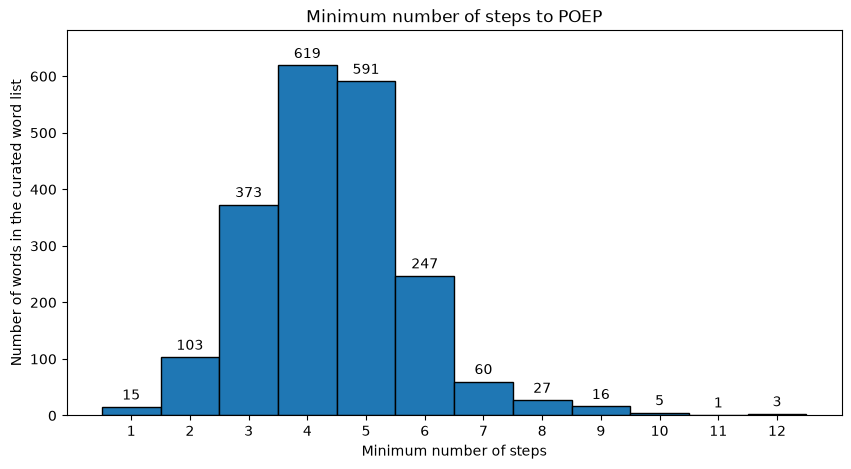

In [ ]:
with open("assets/basiswoorden.txt", "r") as f:
    curated_wordlist = f.read().splitlines()

curated_four_letter_words = libs.select_four_letter_words(curated_wordlist, target_word)
curated_steps = [
    steps_by_word[word] for word in curated_four_letter_words if word in steps_by_word
]

if not curated_steps:
    raise ValueError(f"No curated word can reach {target_word}")

first_step = min(curated_steps)
last_step = max(curated_steps)
bin_edges = [step - 0.5 for step in range(first_step, last_step + 2)]

fig, ax = plt.subplots(figsize=(10, 5))
counts, _, bars = ax.hist(curated_steps, bins=bin_edges, edgecolor="black")
ax.bar_label(bars, labels=[str(int(count)) for count in counts], padding=3)
ax.set(
    title=f"Minimum number of steps to {target_word}",
    xlabel="Minimum number of steps",
    ylabel="Number of words in the curated word list",
)
ax.set_xticks(range(first_step, last_step + 1))
ax.set_ylim(top=max(counts) * 1.1)
plt.show()

In [22]:
assessment = libs.assess_common_dutch_word(start_word)
if assessment.common is None:
    print(f"Waarschuwing: {assessment.warning}")
else:
    verdict = "Ja" if assessment.common else "Nee"
    print(f"{verdict}: {assessment.reason}")

Ja: HUBS is een gangbaar Nederlands woord van precies vier letters.
